# Master amplification ridge scan

This notebook scans fuel concentration and a selected leak parameter to calculate:

1. normalized amplification as a function of time and fuel,
2. optimal fuel concentration at each time,
3. maximum achievable amplification at each time,
4. maximum amplification over time across leak and fuel,
5. the time at which maximum amplification occurs.

The fitting configuration is loaded from JSON, while the fitted solution is loaded from the saved `.npz` results file.

In [1]:
# ============================================================
# 0) IMPORT PACKAGES
# ============================================================

import copy
import json
import sys

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

In [2]:
# ============================================================
# 1) PATHS AND USER CHOICES
# ============================================================

# ------------------------------------------------------------
# Define the main project directory
# ------------------------------------------------------------

BASE_DIR = Path.cwd()

if str(BASE_DIR) not in sys.path:
    sys.path.append(str(BASE_DIR))


# ------------------------------------------------------------
# Import the model registry
# ------------------------------------------------------------

from model_registry import get_model


# ------------------------------------------------------------
# Choose the fitted model/config and results files
# ------------------------------------------------------------

CONFIG_FILE = (
    BASE_DIR
    / "configs"
    / "Fig4H"
    / "fit_exps12345_model3.json"
)

RESULTS_FILE = (
    BASE_DIR
    / "results"
    / "Fig4H"
    / "fit_exps12345_model3.npz"
)


# ------------------------------------------------------------
# Select the leak parameter to scan
#
# Model 3 example:
#     kmG_F
#
# Model 2 example:
#     klk
# ------------------------------------------------------------

LEAK_PARAM = "kmG_F"


# ------------------------------------------------------------
# Select ON and OFF input concentrations
# ------------------------------------------------------------

IN_CONC = 2.5
IN_OFF = 0.0


# ------------------------------------------------------------
# Select the gate-template concentration
# ------------------------------------------------------------

GATE_CONC = 25.0


# ------------------------------------------------------------
# Fuel concentration scan
# ------------------------------------------------------------

FUELS = np.linspace(
    0.0,
    50.0,
    51,
)


# ------------------------------------------------------------
# Leak-parameter scan
# ------------------------------------------------------------

LEAK_VALUES = np.logspace(
    -7,
    -2,
    31,
)


# ------------------------------------------------------------
# Simulation time
#
# The model uses seconds internally.
# Plots use minutes.
# ------------------------------------------------------------

T_END_MIN = 200.0
N_TIME_POINTS = 600

T_EVAL = np.linspace(
    0.0,
    T_END_MIN * 60.0,
    N_TIME_POINTS,
)

TIME_MIN = T_EVAL / 60.0


# ------------------------------------------------------------
# Numerical solver settings
# ------------------------------------------------------------

SOLVER_METHOD = "LSODA"

RTOL = 1e-6
ATOL = 1e-6


# ------------------------------------------------------------
# Numerical rate floor
# ------------------------------------------------------------

RATE_FLOOR = 1e-12


# ------------------------------------------------------------
# Selected fuel values for line plots
# ------------------------------------------------------------

FUEL_VALUES_TO_PLOT = [
    0.0,
    10.0,
    25.0,
    50.0,
]

## Loading the fitted solution

The config stores the model and fitting setup. The `.npz` file stores the numerical fit result.

The loader below supports several common saved formats:

- a parameter dictionary such as `best_params`,
- separate parameter names and values,
- a fitted vector such as `best_x` together with `fit_params` from the config.

For your fitting workflow, `best_x` is assumed to contain base-10 logarithms when no explicit linear vector is saved.

In [3]:
# ============================================================
# 2) LOAD CONFIGURATION, FITTED PARAMETERS, AND MODEL
# ============================================================

# ------------------------------------------------------------
# Check that the selected files exist
# ------------------------------------------------------------

if not CONFIG_FILE.exists():
    raise FileNotFoundError(
        f"Config file not found:\n{CONFIG_FILE}"
    )

if not RESULTS_FILE.exists():
    raise FileNotFoundError(
        f"Results file not found:\n{RESULTS_FILE}"
    )


# ------------------------------------------------------------
# Read the JSON configuration
# ------------------------------------------------------------

with open(CONFIG_FILE, "r") as f:
    config = json.load(f)


# ------------------------------------------------------------
# Identify the model name
# ------------------------------------------------------------

if "model" in config:

    MODEL_NAME = config["model"]

elif "model_name" in config:

    MODEL_NAME = config["model_name"]

else:

    raise KeyError(
        "Could not find 'model' or 'model_name' "
        "in the config file."
    )


# ------------------------------------------------------------
# Load model functions from the registry
# ------------------------------------------------------------

model = get_model(MODEL_NAME)

rhs = model.rhs
initial_conditions = model.initial_conditions
output_index = model.output_index


# ------------------------------------------------------------
# Read the saved NPZ fitting result
# ------------------------------------------------------------

fit_results = np.load(
    RESULTS_FILE,
    allow_pickle=True,
)

print("Saved NPZ keys:")
print(list(fit_results.files))


# ------------------------------------------------------------
# Helper function for unpacking dictionaries saved in NPZ
# ------------------------------------------------------------

def unpack_saved_dictionary(value):

    if isinstance(value, np.ndarray) and value.shape == ():
        value = value.item()

    if isinstance(value, dict):
        return copy.deepcopy(value)

    return None


# ------------------------------------------------------------
# First try to load a complete saved parameter dictionary
# ------------------------------------------------------------

fitted_params = None

for key in [
    "fitted_params",
    "fitted_parameters",
    "best_params",
    "best_parameters",
    "parameters",
    "params",
]:

    if key in fit_results.files:

        fitted_params = unpack_saved_dictionary(
            fit_results[key]
        )

        if fitted_params is not None:
            break


# ------------------------------------------------------------
# Otherwise reconstruct the dictionary from a fitted vector
# ------------------------------------------------------------

if fitted_params is None:

    # --------------------------------------------------------
    # Find the fitted parameter names
    # --------------------------------------------------------

    if "fit_params" in config:

        fit_param_names = list(
            config["fit_params"]
        )

    elif "FIT_PARAMS" in config:

        fit_param_names = list(
            config["FIT_PARAMS"]
        )

    elif "parameter_names" in fit_results.files:

        fit_param_names = [
            str(name)
            for name in fit_results["parameter_names"].tolist()
        ]

    elif "fit_params" in fit_results.files:

        fit_param_names = [
            str(name)
            for name in fit_results["fit_params"].tolist()
        ]

    else:

        raise KeyError(
            "Could not determine the fitted parameter names. "
            "Expected 'fit_params' in the config or NPZ file."
        )


    # --------------------------------------------------------
    # Find the saved fitted parameter vector
    # --------------------------------------------------------

    vector_is_log10 = False

    if "best_x_log10" in fit_results.files:

        fitted_vector = np.asarray(
            fit_results["best_x_log10"],
            dtype=float,
        )

        vector_is_log10 = True

    elif "best_log_params" in fit_results.files:

        fitted_vector = np.asarray(
            fit_results["best_log_params"],
            dtype=float,
        )

        vector_is_log10 = True

    elif "best_x" in fit_results.files:

        fitted_vector = np.asarray(
            fit_results["best_x"],
            dtype=float,
        )

        # The fitting notebooks optimize positive parameters
        # in base-10 logarithmic space.
        vector_is_log10 = True

    elif "x" in fit_results.files:

        fitted_vector = np.asarray(
            fit_results["x"],
            dtype=float,
        )

        vector_is_log10 = True

    elif "best_values" in fit_results.files:

        fitted_vector = np.asarray(
            fit_results["best_values"],
            dtype=float,
        )

        vector_is_log10 = False

    else:

        raise KeyError(
            "Could not find a fitted parameter vector in the "
            "NPZ file. Expected 'best_x', 'best_x_log10', "
            "'best_values', or a saved parameter dictionary."
        )


    # --------------------------------------------------------
    # Check vector length
    # --------------------------------------------------------

    fitted_vector = fitted_vector.reshape(-1)

    if len(fitted_vector) != len(fit_param_names):

        raise ValueError(
            "The number of fitted values does not match the "
            "number of fitted parameter names.\n"
            f"Values: {len(fitted_vector)}\n"
            f"Names : {len(fit_param_names)}"
        )


    # --------------------------------------------------------
    # Convert the fitted vector to linear parameter values
    # --------------------------------------------------------

    if vector_is_log10:

        fitted_values = 10.0 ** fitted_vector

    else:

        fitted_values = fitted_vector


    # --------------------------------------------------------
    # Begin with any fixed/default parameters stored in config
    # --------------------------------------------------------

    fitted_params = {}

    for key in [
        "default_params",
        "nominal_params",
        "fixed_params",
        "params",
    ]:

        if key in config and isinstance(config[key], dict):

            fitted_params.update(
                copy.deepcopy(config[key])
            )


    # --------------------------------------------------------
    # Insert the fitted values
    # --------------------------------------------------------

    for parameter_name, parameter_value in zip(
        fit_param_names,
        fitted_values,
    ):

        fitted_params[parameter_name] = float(
            parameter_value
        )


# ------------------------------------------------------------
# Convert scalar parameter values to floats
# ------------------------------------------------------------

clean_params = {}

for parameter_name, parameter_value in fitted_params.items():

    value_array = np.asarray(parameter_value)

    if value_array.size != 1:

        raise ValueError(
            f"Parameter '{parameter_name}' is not scalar."
        )

    clean_params[parameter_name] = float(
        value_array.reshape(-1)[0]
    )

fitted_params = clean_params


# ------------------------------------------------------------
# Confirm that the scanned leak parameter exists
# ------------------------------------------------------------

if LEAK_PARAM not in fitted_params:

    print("\nLoaded parameter names:")
    print(list(fitted_params.keys()))

    raise KeyError(
        f"The selected leak parameter '{LEAK_PARAM}' "
        "was not found in the fitted parameter dictionary."
    )


# ------------------------------------------------------------
# Print loaded settings
# ------------------------------------------------------------

print("\nLoaded amplification scan")
print("-" * 60)

print(f"Config file : {CONFIG_FILE}")
print(f"Results file: {RESULTS_FILE}")
print(f"Model       : {MODEL_NAME}")
print(f"Leak scan   : {LEAK_PARAM}")
print(f"Fitted leak : {fitted_params[LEAK_PARAM]:.6e}")
print(f"Input ON    : {IN_CONC} nM")
print(f"Input OFF   : {IN_OFF} nM")
print(f"Gate        : {GATE_CONC} nM")
print(f"Fuel range  : {FUELS[0]} to {FUELS[-1]} nM")

print(
    f"Leak range  : "
    f"{LEAK_VALUES[0]:.2e} to {LEAK_VALUES[-1]:.2e}"
)

print(f"Time range  : 0 to {T_END_MIN} min")


# ------------------------------------------------------------
# Print fitted parameters
# ------------------------------------------------------------

print("\nFitted parameters")
print("-" * 60)

for parameter_name, parameter_value in fitted_params.items():

    print(
        f"{parameter_name:<18s}: "
        f"{parameter_value:.6e}"
    )

Saved NPZ keys:
['best_x', 'best_cost', 'fit_params']

Loaded amplification scan
------------------------------------------------------------
Config file : /Users/nt625/Library/CloudStorage/OneDrive-DrexelUniversity/_DrexelNist_/GITHUB-Predictive-Analysis-of-Amplification-in-Biochemical-Feedback-Circuits/configs/Fig4H/fit_exps12345_model3.json
Results file: /Users/nt625/Library/CloudStorage/OneDrive-DrexelUniversity/_DrexelNist_/GITHUB-Predictive-Analysis-of-Amplification-in-Biochemical-Feedback-Circuits/results/Fig4H/fit_exps12345_model3.npz
Model       : model3_misfoldgate_fuel
Leak scan   : kmG_F
Fitted leak : 9.979247e-07
Input ON    : 2.5 nM
Input OFF   : 0.0 nM
Gate        : 25.0 nM
Fuel range  : 0.0 to 50.0 nM
Leak range  : 1.00e-07 to 1.00e-02
Time range  : 0 to 200.0 min

Fitted parameters
------------------------------------------------------------
k_txn             : 1.031077e-02
ksd               : 5.512475e-05
kfsd              : 1.369860e-06
krev              : 3.706611e-

In [4]:
# ============================================================
# 3) HELPER FUNCTIONS
# ============================================================

def make_condition(
    input_conc,
    fuel_conc,
    gate_conc,
):
    """Create the condition dictionary used by the model."""

    condition = {
        "RSD_temp": float(gate_conc),
        "IN_temp": float(input_conc),
        "F_temp": float(fuel_conc),
    }

    # Use a configured reporter concentration when available.
    if "DRL0" in config:

        condition["DRL0"] = float(
            config["DRL0"]
        )

    elif "reporter_total" in config:

        condition["DRL0"] = float(
            config["reporter_total"]
        )

    else:

        condition["DRL0"] = 500.0

    return condition



def simulate_condition(
    input_conc,
    fuel_conc,
    gate_conc,
    params,
):
    """Simulate one input, fuel, and gate condition."""

    condition = make_condition(
        input_conc=input_conc,
        fuel_conc=fuel_conc,
        gate_conc=gate_conc,
    )

    x0 = initial_conditions(
        condition,
        params,
    )

    solution = solve_ivp(
        fun=lambda t, x: rhs(
            t,
            x,
            condition["RSD_temp"],
            condition["IN_temp"],
            condition["F_temp"],
            params,
        ),
        t_span=(
            T_EVAL[0],
            T_EVAL[-1],
        ),
        y0=x0,
        t_eval=T_EVAL,
        method=SOLVER_METHOD,
        rtol=RTOL,
        atol=ATOL,
    )

    if not solution.success:

        raise RuntimeError(
            "ODE integration failed for "
            f"input={input_conc}, "
            f"fuel={fuel_conc}, "
            f"gate={gate_conc}. "
            f"Solver message: {solution.message}"
        )

    return solution



def calculate_output_rate(
    solution,
    input_conc,
    fuel_conc,
    gate_conc,
    params,
):
    """Evaluate dROL/dt directly from the model RHS."""

    output_rate = np.zeros(
        solution.t.size,
        dtype=float,
    )

    for time_index in range(
        solution.t.size
    ):

        dxdt = rhs(
            solution.t[time_index],
            solution.y[:, time_index],
            float(gate_conc),
            float(input_conc),
            float(fuel_conc),
            params,
        )

        output_rate[time_index] = dxdt[
            output_index
        ]

    return output_rate



def safe_positive_rate(
    rate,
    floor=RATE_FLOOR,
):
    """Apply a small positive floor before taking ratios."""

    rate = np.asarray(
        rate,
        dtype=float,
    )

    return np.where(
        np.isfinite(rate) & (rate > floor),
        rate,
        floor,
    )



def simulate_output_rate(
    input_conc,
    fuel_conc,
    gate_conc,
    params,
):
    """Simulate a condition and return its output rate."""

    solution = simulate_condition(
        input_conc=input_conc,
        fuel_conc=fuel_conc,
        gate_conc=gate_conc,
        params=params,
    )

    return calculate_output_rate(
        solution=solution,
        input_conc=input_conc,
        fuel_conc=fuel_conc,
        gate_conc=gate_conc,
        params=params,
    )



def calculate_amplification_surface(
    params,
):
    """
    Calculate normalized amplification for every fuel value.

    A0(t, f) = rate_ON(t, f) / rate_OFF(t, f)

    A(t, f) = A0(t, f) / A0(t, 0)
    """

    amplification = np.full(
        (
            len(FUELS),
            len(T_EVAL),
        ),
        np.nan,
    )


    # --------------------------------------------------------
    # Calculate the zero-fuel reference only once
    # --------------------------------------------------------

    rate_on_reference = simulate_output_rate(
        input_conc=IN_CONC,
        fuel_conc=0.0,
        gate_conc=GATE_CONC,
        params=params,
    )

    rate_off_reference = simulate_output_rate(
        input_conc=IN_OFF,
        fuel_conc=0.0,
        gate_conc=GATE_CONC,
        params=params,
    )

    rate_on_reference = safe_positive_rate(
        rate_on_reference
    )

    rate_off_reference = safe_positive_rate(
        rate_off_reference
    )

    reference_ratio = safe_positive_rate(
        rate_on_reference
        / rate_off_reference
    )


    # --------------------------------------------------------
    # Calculate amplification at every fuel concentration
    # --------------------------------------------------------

    for fuel_index, fuel_conc in enumerate(
        FUELS
    ):

        rate_on = simulate_output_rate(
            input_conc=IN_CONC,
            fuel_conc=fuel_conc,
            gate_conc=GATE_CONC,
            params=params,
        )

        rate_off = simulate_output_rate(
            input_conc=IN_OFF,
            fuel_conc=fuel_conc,
            gate_conc=GATE_CONC,
            params=params,
        )

        rate_on = safe_positive_rate(
            rate_on
        )

        rate_off = safe_positive_rate(
            rate_off
        )

        fuel_ratio = (
            rate_on
            / rate_off
        )

        amplification[
            fuel_index,
            :,
        ] = (
            fuel_ratio
            / reference_ratio
        )

    return amplification

In [5]:
# ============================================================
# 4) AMPLIFICATION SURFACE AT THE FITTED LEAK RATE
# ============================================================

print(
    "Calculating fitted-parameter amplification surface..."
)

amplification_fitted = (
    calculate_amplification_surface(
        fitted_params
    )
)

amplification_fitted[
    ~np.isfinite(amplification_fitted)
] = np.nan


# ------------------------------------------------------------
# Identify the optimal fuel and maximum amplification
# at each time point
# ------------------------------------------------------------

optimal_fuel_index = np.nanargmax(
    amplification_fitted,
    axis=0,
)

optimal_fuel_over_time = FUELS[
    optimal_fuel_index
]

max_amplification_over_time = np.nanmax(
    amplification_fitted,
    axis=0,
)

Calculating fitted-parameter amplification surface...


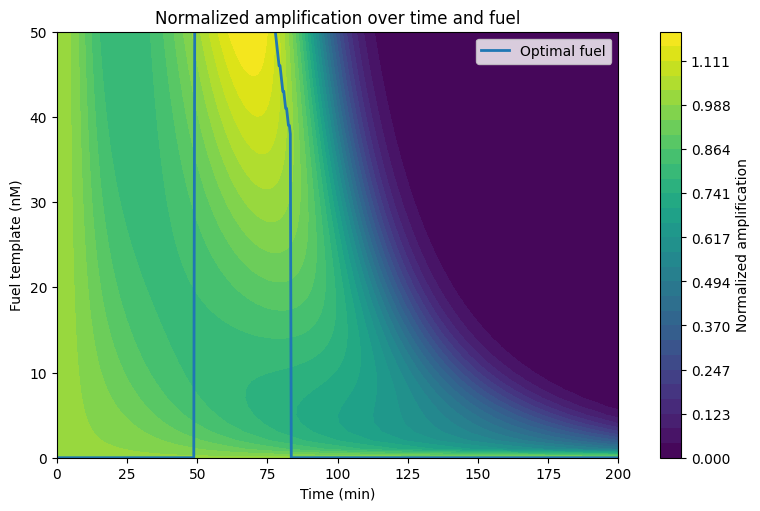

In [6]:
# ============================================================
# 5) PLOT AMPLIFICATION AS A FUNCTION OF TIME AND FUEL
# ============================================================

fig, ax = plt.subplots(
    figsize=(7.5, 5.0),
    constrained_layout=True,
)

amp_min = np.nanmin(
    amplification_fitted
)

amp_max = np.nanmax(
    amplification_fitted
)

if np.isclose(
    amp_min,
    amp_max,
):

    amp_levels = 20

else:

    amp_levels = np.linspace(
        amp_min,
        amp_max,
        30,
    )

amp_surface_plot = ax.contourf(
    TIME_MIN,
    FUELS,
    amplification_fitted,
    levels=amp_levels,
    cmap="viridis",
)

ax.plot(
    TIME_MIN,
    optimal_fuel_over_time,
    linewidth=2.0,
    label="Optimal fuel",
)

ax.set_xlabel("Time (min)")
ax.set_ylabel("Fuel template (nM)")
ax.set_title(
    "Normalized amplification over time and fuel"
)

ax.legend()

amp_surface_cbar = fig.colorbar(
    amp_surface_plot,
    ax=ax,
)

amp_surface_cbar.set_label(
    "Normalized amplification"
)

plt.show()

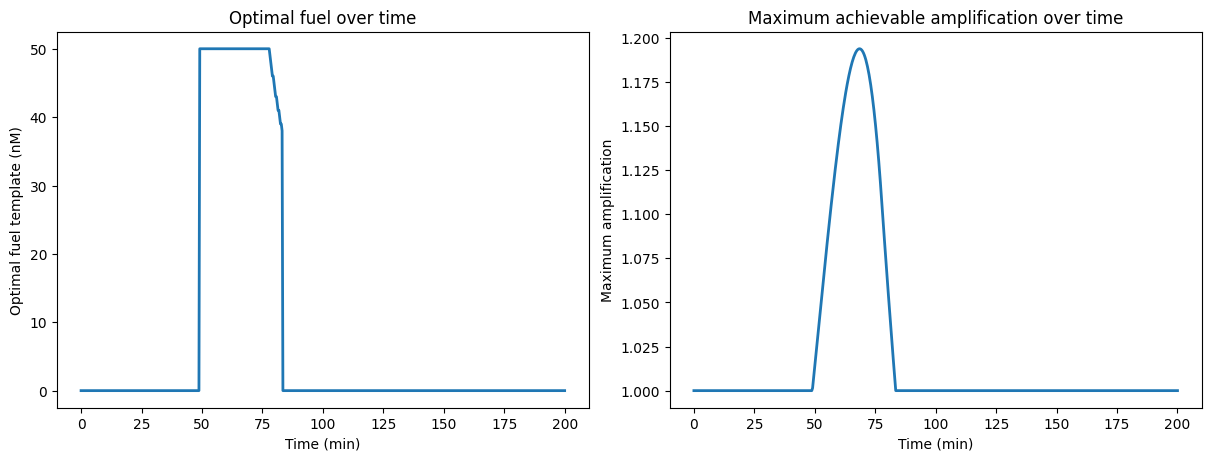

In [7]:
# ============================================================
# 6) PLOT OPTIMAL FUEL AND MAXIMUM AMPLIFICATION OVER TIME
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.5),
    constrained_layout=True,
)

axes[0].plot(
    TIME_MIN,
    optimal_fuel_over_time,
    linewidth=2.0,
)

axes[0].set_xlabel("Time (min)")
axes[0].set_ylabel(
    "Optimal fuel template (nM)"
)
axes[0].set_title(
    "Optimal fuel over time"
)

axes[1].plot(
    TIME_MIN,
    max_amplification_over_time,
    linewidth=2.0,
)

axes[1].set_xlabel("Time (min)")
axes[1].set_ylabel(
    "Maximum amplification"
)
axes[1].set_title(
    "Maximum achievable amplification over time"
)

plt.show()

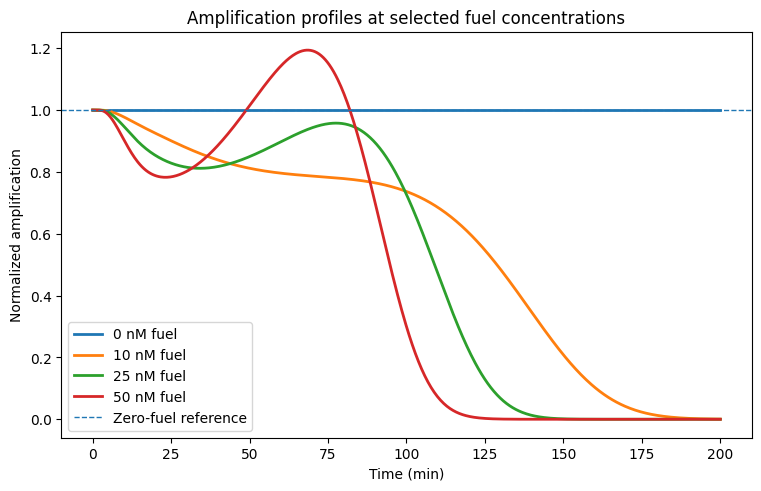

In [8]:
# ============================================================
# 7) PLOT AMPLIFICATION LINE SCANS
# ============================================================

fig, ax = plt.subplots(
    figsize=(7.5, 4.8),
    constrained_layout=True,
)

for requested_fuel in FUEL_VALUES_TO_PLOT:

    fuel_index = np.argmin(
        np.abs(
            FUELS - requested_fuel
        )
    )

    actual_fuel = FUELS[
        fuel_index
    ]

    ax.plot(
        TIME_MIN,
        amplification_fitted[
            fuel_index,
            :,
        ],
        linewidth=2.0,
        label=f"{actual_fuel:g} nM fuel",
    )

ax.axhline(
    1.0,
    linestyle="--",
    linewidth=1.0,
    label="Zero-fuel reference",
)

ax.set_xlabel("Time (min)")
ax.set_ylabel(
    "Normalized amplification"
)
ax.set_title(
    "Amplification profiles at selected fuel concentrations"
)

ax.legend()

plt.show()

In [9]:
# ============================================================
# 8) SCAN LEAK RATE AND FUEL CONCENTRATION
# ============================================================

# ------------------------------------------------------------
# Allocate summary matrices
# ------------------------------------------------------------

max_amp_over_time = np.full(
    (
        len(LEAK_VALUES),
        len(FUELS),
    ),
    np.nan,
)

time_of_max_amp = np.full(
    (
        len(LEAK_VALUES),
        len(FUELS),
    ),
    np.nan,
)

optimal_fuel_by_leak = np.full(
    (
        len(LEAK_VALUES),
        len(T_EVAL),
    ),
    np.nan,
)

maximum_amp_by_leak = np.full(
    (
        len(LEAK_VALUES),
        len(T_EVAL),
    ),
    np.nan,
)


print(
    "Scanning leak rate and fuel concentration..."
)
print("-" * 60)


# ------------------------------------------------------------
# Loop over leak values
# ------------------------------------------------------------

for leak_index, leak_value in enumerate(
    LEAK_VALUES
):

    scan_params = copy.deepcopy(
        fitted_params
    )

    scan_params[
        LEAK_PARAM
    ] = float(
        leak_value
    )

    amplification_surface = (
        calculate_amplification_surface(
            scan_params
        )
    )

    amplification_surface[
        ~np.isfinite(
            amplification_surface
        )
    ] = np.nan


    # --------------------------------------------------------
    # Maximum over time for each fuel
    # --------------------------------------------------------

    max_amp_over_time[
        leak_index,
        :,
    ] = np.nanmax(
        amplification_surface,
        axis=1,
    )


    # --------------------------------------------------------
    # Time at which each fuel reaches its maximum
    # --------------------------------------------------------

    max_time_indices = np.nanargmax(
        amplification_surface,
        axis=1,
    )

    time_of_max_amp[
        leak_index,
        :,
    ] = TIME_MIN[
        max_time_indices
    ]


    # --------------------------------------------------------
    # Optimal fuel and maximum amplification at each time
    # --------------------------------------------------------

    optimal_indices = np.nanargmax(
        amplification_surface,
        axis=0,
    )

    optimal_fuel_by_leak[
        leak_index,
        :,
    ] = FUELS[
        optimal_indices
    ]

    maximum_amp_by_leak[
        leak_index,
        :,
    ] = np.nanmax(
        amplification_surface,
        axis=0,
    )

    print(
        f"Leak {leak_index + 1:02d}/"
        f"{len(LEAK_VALUES)}: "
        f"{LEAK_PARAM} = {leak_value:.3e}"
    )


print(
    "\nLeak-fuel scan complete."
)

Scanning leak rate and fuel concentration...
------------------------------------------------------------
Leak 01/31: kmG_F = 1.000e-07
Leak 02/31: kmG_F = 1.468e-07
Leak 03/31: kmG_F = 2.154e-07
Leak 04/31: kmG_F = 3.162e-07
Leak 05/31: kmG_F = 4.642e-07
Leak 06/31: kmG_F = 6.813e-07
Leak 07/31: kmG_F = 1.000e-06
Leak 08/31: kmG_F = 1.468e-06
Leak 09/31: kmG_F = 2.154e-06
Leak 10/31: kmG_F = 3.162e-06
Leak 11/31: kmG_F = 4.642e-06
Leak 12/31: kmG_F = 6.813e-06
Leak 13/31: kmG_F = 1.000e-05
Leak 14/31: kmG_F = 1.468e-05
Leak 15/31: kmG_F = 2.154e-05
Leak 16/31: kmG_F = 3.162e-05
Leak 17/31: kmG_F = 4.642e-05
Leak 18/31: kmG_F = 6.813e-05
Leak 19/31: kmG_F = 1.000e-04
Leak 20/31: kmG_F = 1.468e-04
Leak 21/31: kmG_F = 2.154e-04
Leak 22/31: kmG_F = 3.162e-04
Leak 23/31: kmG_F = 4.642e-04
Leak 24/31: kmG_F = 6.813e-04
Leak 25/31: kmG_F = 1.000e-03
Leak 26/31: kmG_F = 1.468e-03
Leak 27/31: kmG_F = 2.154e-03
Leak 28/31: kmG_F = 3.162e-03
Leak 29/31: kmG_F = 4.642e-03
Leak 30/31: kmG_F = 6.81

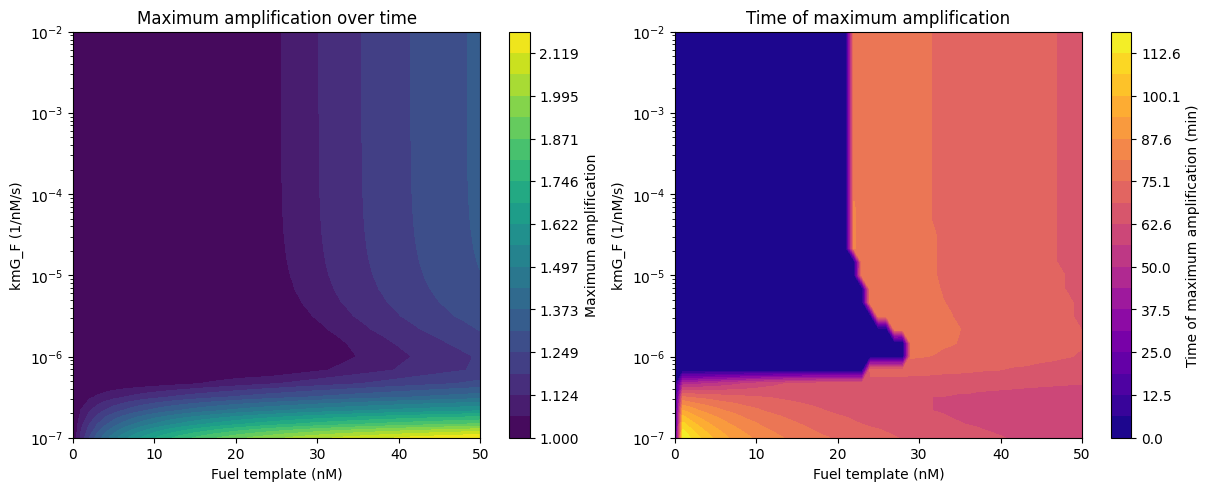

In [10]:
# ============================================================
# 9) PLOT MAXIMUM AMPLIFICATION AND TIME-OF-MAX HEATMAPS
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.8),
    constrained_layout=True,
)


# ------------------------------------------------------------
# Left: maximum amplification over time
# ------------------------------------------------------------

axes[0].set_yscale("log")
axes[0].set_xlabel(
    "Fuel template (nM)"
)
axes[0].set_ylabel(
    f"{LEAK_PARAM} (1/nM/s)"
)
axes[0].set_title(
    "Maximum amplification over time"
)

amp_min = np.nanmin(
    max_amp_over_time
)

amp_max = np.nanmax(
    max_amp_over_time
)

if np.isclose(
    amp_min,
    amp_max,
):

    levels_amp = 20

else:

    levels_amp = np.linspace(
        amp_min,
        amp_max,
        20,
    )

amp_plot = axes[0].contourf(
    FUELS,
    LEAK_VALUES,
    max_amp_over_time,
    levels=levels_amp,
    cmap="viridis",
)

amp_cbar = fig.colorbar(
    amp_plot,
    ax=axes[0],
)

amp_cbar.set_label(
    "Maximum amplification"
)


# ------------------------------------------------------------
# Right: time where maximum amplification occurs
# ------------------------------------------------------------

axes[1].set_yscale("log")
axes[1].set_xlabel(
    "Fuel template (nM)"
)
axes[1].set_ylabel(
    f"{LEAK_PARAM} (1/nM/s)"
)
axes[1].set_title(
    "Time of maximum amplification"
)

time_minimum = np.nanmin(
    time_of_max_amp
)

time_maximum = np.nanmax(
    time_of_max_amp
)

if np.isclose(
    time_minimum,
    time_maximum,
):

    levels_time = 20

else:

    levels_time = np.linspace(
        time_minimum,
        time_maximum,
        20,
    )

time_plot = axes[1].contourf(
    FUELS,
    LEAK_VALUES,
    time_of_max_amp,
    levels=levels_time,
    cmap="plasma",
)

time_cbar = fig.colorbar(
    time_plot,
    ax=axes[1],
)

time_cbar.set_label(
    "Time of maximum amplification (min)"
)

plt.show()

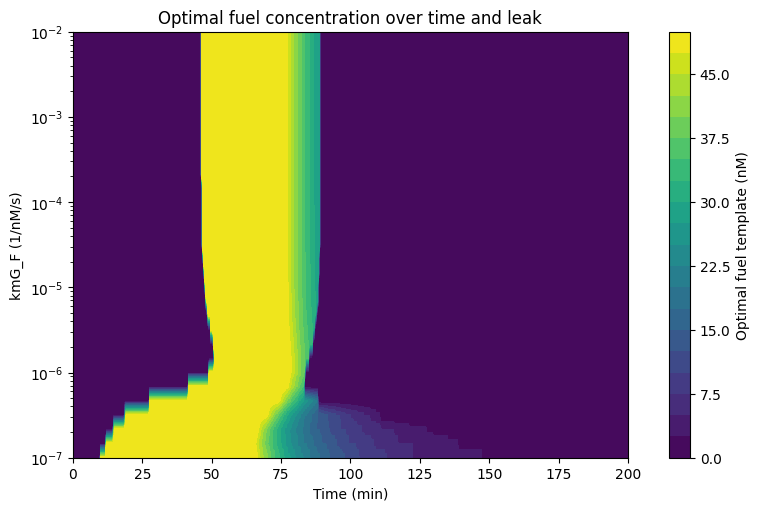

In [11]:
# ============================================================
# 10) PLOT OPTIMAL FUEL AS A FUNCTION OF TIME AND LEAK
# ============================================================

fig, ax = plt.subplots(
    figsize=(7.5, 5.0),
    constrained_layout=True,
)

fuel_min = np.nanmin(
    optimal_fuel_by_leak
)

fuel_max = np.nanmax(
    optimal_fuel_by_leak
)

if np.isclose(
    fuel_min,
    fuel_max,
):

    fuel_levels = 20

else:

    fuel_levels = np.linspace(
        fuel_min,
        fuel_max,
        21,
    )

optimal_fuel_plot = ax.contourf(
    TIME_MIN,
    LEAK_VALUES,
    optimal_fuel_by_leak,
    levels=fuel_levels,
    cmap="viridis",
)

ax.set_yscale("log")
ax.set_xlabel("Time (min)")
ax.set_ylabel(
    f"{LEAK_PARAM} (1/nM/s)"
)
ax.set_title(
    "Optimal fuel concentration over time and leak"
)

optimal_fuel_cbar = fig.colorbar(
    optimal_fuel_plot,
    ax=ax,
)

optimal_fuel_cbar.set_label(
    "Optimal fuel template (nM)"
)

plt.show()

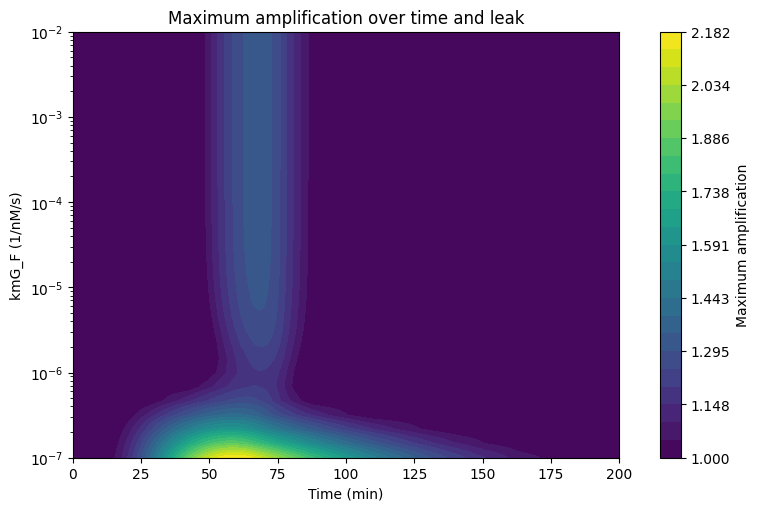

In [12]:
# ============================================================
# 11) PLOT MAXIMUM AMPLIFICATION AS A FUNCTION OF TIME AND LEAK
# ============================================================

fig, ax = plt.subplots(
    figsize=(7.5, 5.0),
    constrained_layout=True,
)

maximum_min = np.nanmin(
    maximum_amp_by_leak
)

maximum_max = np.nanmax(
    maximum_amp_by_leak
)

if np.isclose(
    maximum_min,
    maximum_max,
):

    maximum_levels = 20

else:

    maximum_levels = np.linspace(
        maximum_min,
        maximum_max,
        25,
    )

maximum_plot = ax.contourf(
    TIME_MIN,
    LEAK_VALUES,
    maximum_amp_by_leak,
    levels=maximum_levels,
    cmap="viridis",
)

ax.set_yscale("log")
ax.set_xlabel("Time (min)")
ax.set_ylabel(
    f"{LEAK_PARAM} (1/nM/s)"
)
ax.set_title(
    "Maximum amplification over time and leak"
)

maximum_cbar = fig.colorbar(
    maximum_plot,
    ax=ax,
)

maximum_cbar.set_label(
    "Maximum amplification"
)

plt.show()

In [13]:
# ============================================================
# 12) REPORT THE FITTED LEAK LOCATION
# ============================================================

fitted_leak = fitted_params[
    LEAK_PARAM
]

nearest_leak_index = np.argmin(
    np.abs(
        np.log10(LEAK_VALUES)
        - np.log10(fitted_leak)
    )
)

nearest_leak = LEAK_VALUES[
    nearest_leak_index
]

best_fuel_index = np.nanargmax(
    max_amp_over_time[
        nearest_leak_index,
        :,
    ]
)

best_fuel = FUELS[
    best_fuel_index
]

best_amplification = max_amp_over_time[
    nearest_leak_index,
    best_fuel_index,
]

best_time = time_of_max_amp[
    nearest_leak_index,
    best_fuel_index,
]


print("Fitted leak comparison")
print("-" * 60)

print(
    f"Fitted {LEAK_PARAM}: "
    f"{fitted_leak:.6e} 1/nM/s"
)

print(
    f"Nearest scanned value: "
    f"{nearest_leak:.6e} 1/nM/s"
)

print(
    f"Best fuel at nearest leak: "
    f"{best_fuel:.2f} nM"
)

print(
    f"Maximum amplification: "
    f"{best_amplification:.4g}"
)

print(
    f"Time of maximum: "
    f"{best_time:.2f} min"
)

Fitted leak comparison
------------------------------------------------------------
Fitted kmG_F: 9.979247e-07 1/nM/s
Nearest scanned value: 1.000000e-06 1/nM/s
Best fuel at nearest leak: 50.00 nM
Maximum amplification: 1.194
Time of maximum: 68.45 min
